# 2025-03-03. Download Sanchis 21

This notebook aims to generate a new index collection to enable the download of Sanchis 2021.

In [32]:
import requests
import pandas as pd
import seaborn as sns

In [16]:
taxids = pd.read_csv("/data/MIRIPVIR25/sanchis21/.taxid", header=None, names=['taxid'])
taxids

,taxid
0,178901
1,441768
2,32002
3,217204
4,72556
...,...
955,698414
956,1444770
957,1735686
958,1288385


In [22]:
def obtain_report(taxid):
    u = requests.get(f"https://api.ncbi.nlm.nih.gov/datasets/v2/genome/taxon/{taxid}/dataset_report")
    u.raise_for_status()
    u = u.json()
    try:
        u = pd.DataFrame.from_records([dict(accession=item['accession'], organism=item['organism']['organism_name'], length=item['assembly_stats']['total_sequence_length']) for item in u['reports']]).sort_values(by='length', ascending=False).reset_index()
    except KeyError:
        return dict(taxid=taxid, organism=None, length=None)
    return dict(taxid=taxid, accesion=u.loc[0, 'accession'], organism=u.loc[0, 'organism'], length=u.loc[0, 'length'])


In [25]:
reports = list(map(obtain_report, taxids['taxid'].unique().tolist()))

In [ ]:
reports = pd.DataFrame.from_records(reports)
reports['length'] = reports['length'].astype(float)

In [31]:
reports.dropna(subset='accesion').to_csv("../data/sanchis21.genome-accesions.csv", sep=";", index=None)

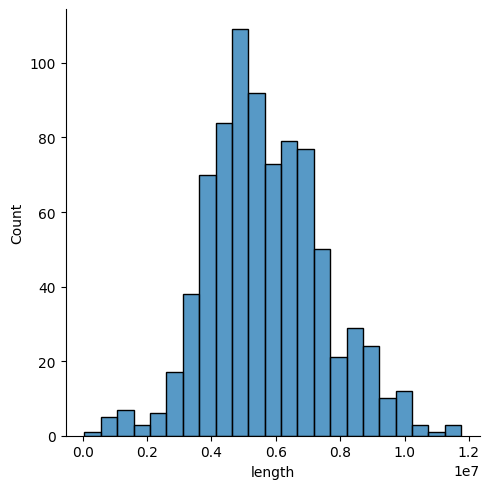

In [37]:
sns.displot(data=reports.dropna(subset='accesion'), x='length')

In [ ]:
reports.